In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
df = pd.read_csv("/Users/apple/Desktop/AI-ML/Datasets/data_science_job.csv")

In [96]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [97]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [98]:
df.shape

(19158, 13)

In [99]:
cols = []

for var in df.columns:
    if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0:
        cols.append(var)
        
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [100]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
6980,0.682,Full time course,Graduate,4.0,24.0
7951,0.926,no_enrollment,Masters,14.0,36.0
1471,0.624,no_enrollment,Graduate,6.0,71.0
15275,0.920,no_enrollment,Graduate,5.0,25.0
11087,0.624,no_enrollment,Masters,8.0,25.0


In [101]:
len(df[cols].dropna())/len(df)

0.8968577095730244

In [102]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

<Axes: >

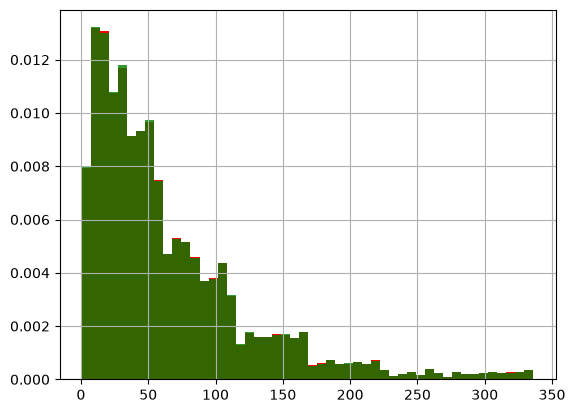

In [103]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

#data after CCA, the argument alpha makes the color transparent, so we can see the overlay of the 2 distribution
new_df['training_hours'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: >

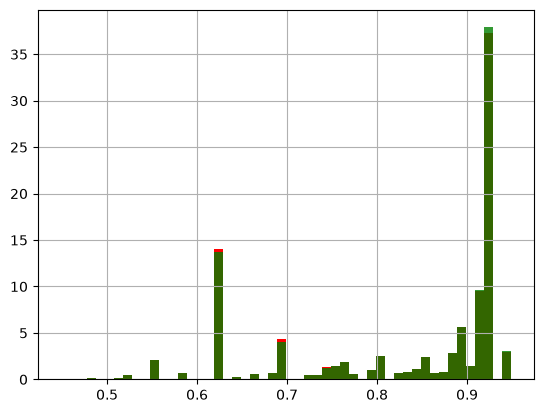

In [104]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

#data after CCA, the argument alpha makes the color transparent, so we can see the overlay of the 2 distribution
new_df['city_development_index'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

<Axes: >

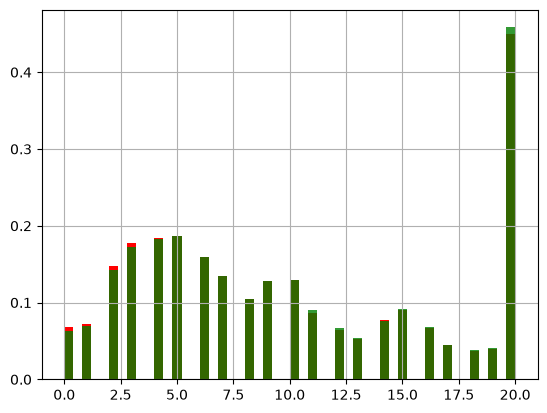

In [105]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

#data after CCA, the argument alpha makes the color transparent, so we can see the overlay of the 2 distribution
new_df['experience'].hist(bins=50, ax=ax, density=True, color='green', alpha=0.8)

In [106]:
temp = pd.concat([
    #percentage of observations per category, original data
    df['enrolled_university'].value_counts()/len(df),
    
    #percentage of observations per category, original data
    new_df['enrolled_university'].value_counts()/len(new_df)   
], axis=1)

#add the columns names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [107]:
temp = pd.concat([
    #percentage of observations per category, original data
    df['education_level'].value_counts()/len(df),
    
    #percentage of observations per category, original data
    new_df['education_level'].value_counts()/len(new_df)   
], axis=1)

#add the columns names
temp.columns = ['original', 'cca']

temp


,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
